# Day 24 - nanoGPT - 从头写一个 GPT

> 目标: 用 ~300 行代码实现一个 mini GPT, 理解每一步
>
> 参考: Andrej Karpathy's nanoGPT

---

## nanoGPT 结构

```
输入 (token IDs)
  |
Token Embedding + Position Embedding
  |
Transformer Block × N
  ├── Multi-Head Causal Self-Attention
  ├── Add & LayerNorm
  └── Feed Forward (MLP) + Add & LayerNorm
  |
LayerNorm
  |
Linear → 预测下一个 token 的概率
```

跟 Day 19 Transformer 的区别:
  - 用 **Causal Mask** (不是全连接) → 只能看左边
  - 没有 Encoder, 只有 Decoder
  - 训练目标: 下一个词预测

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 24 - nanoGPT')
print('=' * 40)

Day 24 - nanoGPT


## 1. Causal Self-Attention

> GPT 的注意力跟 BERT 的唯一区别: **遮住右边**
>
> 用下三角矩阵实现: 每个位置只能看自己和左边

In [21]:
class CausalSelfAttention(nn.Module):
    """带因果掩码的多头自注意力 (GPT 用的)"""
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads

        self.W_qkv = nn.Linear(d_model, 3 * d_model)  # 合并 QKV
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape  # batch, seq_len, d_model

        qkv = self.W_qkv(x).reshape(B, T, 3, self.n_heads, self.d_k)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, nh, T, d_k)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Scaled Dot-Product
        scores = q @ k.transpose(-2, -1) / np.sqrt(self.d_k)  # (B, nh, T, T)

        # Causal Mask: 右上角填 -inf (softmax 后变成 0)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores.masked_fill_(mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        out = attn @ v  # (B, nh, T, d_k)

        out = out.transpose(1, 2).reshape(B, T, C)
        return self.W_o(out), attn


# 测试
B, T, C, nh = 2, 6, 16, 4
attn = CausalSelfAttention(C, nh)
x = torch.randn(B, T, C)
out, attn_weights = attn(x)

print(f'输入: {tuple(x.shape)}')
print(f'输出: {tuple(out.shape)}')
print(f'注意力: {tuple(attn_weights.shape)}')

# 验证 causal mask 有效
first_head = attn_weights[0, 0].detach().numpy()
print(f'\n第一个 head 的注意力矩阵 (右上角应为 0):')
np.set_printoptions(precision=2, suppress=True)
print(first_head.round(2))

输入: (2, 6, 16)
输出: (2, 6, 16)
注意力: (2, 4, 6, 6)

第一个 head 的注意力矩阵 (右上角应为 0):
[[1.   0.   0.   0.   0.   0.  ]
 [0.74 0.26 0.   0.   0.   0.  ]
 [0.39 0.28 0.32 0.   0.   0.  ]
 [0.36 0.16 0.26 0.22 0.   0.  ]
 [0.16 0.25 0.2  0.19 0.2  0.  ]
 [0.2  0.16 0.17 0.2  0.12 0.15]]


## 2. Transformer Decoder Block

> Attention + MLP + 残差连接 + LayerNorm
>
> 跟 Day 19 Encoder 一样, 只是 Attention 换成了 Causal

In [22]:
class MLP(nn.Module):
    """两层前馈网络 (FFN)"""
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.gelu = nn.GELU()  # GPT 用 GELU 不是 ReLU

    def forward(self, x):
        return self.fc2(self.gelu(self.fc1(x)))


class TransformerDecoderBlock(nn.Module):
    """一个 Transformer Decoder 层"""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = CausalSelfAttention(d_model, n_heads)
        self.mlp = MLP(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        # Attention + 残差
        attn_out, _ = self.attn(self.norm1(x))
        x = x + self.drop1(attn_out)
        # MLP + 残差
        mlp_out = self.mlp(self.norm2(x))
        x = x + self.drop2(mlp_out)
        return x

## 3. nanoGPT 完整模型

> 把 Embedding + N 层 Decoder + 输出头拼起来

In [29]:
class NanoGPT(nn.Module):
    """微型 GPT: token embedding + pos embedding + N × Decoder + lm_head"""
    def __init__(self, vocab_size, d_model=128, n_heads=4, d_ff=256,
                 n_layers=4, max_len=64, dropout=0.1):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.blocks = nn.Sequential(*[
            TransformerDecoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(0, T, device=x.device).unsqueeze(0)
        x = self.token_embed(x) + self.pos_embed(pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

    def generate(self, x, max_new=50, temperature=1.0):
        """自回归生成: 每次预测一个 token, 拼回去继续"""
        self.eval()
        with torch.no_grad():
            for _ in range(max_new):
                # 只取最后 max_len 个 token (超出长度就截断)
                x_cond = x[:, -self.pos_embed.num_embeddings:]
                logits = self.forward(x_cond)
                logits = logits[:, -1, :] / temperature
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                x = torch.cat([x, next_token], dim=1)
        return x


# 创建模型
model = NanoGPT(vocab_size=100, d_model=64, n_heads=4, d_ff=256, n_layers=4)
print(f'nanoGPT 参数量: {sum(p.numel() for p in model.parameters()):,}')
print(model)

nanoGPT 参数量: 217,060
NanoGPT(
  (token_embed): Embedding(100, 64)
  (pos_embed): Embedding(64, 64)
  (blocks): Sequential(
    (0): TransformerDecoderBlock(
      (attn): CausalSelfAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (mlp): MLP(
        (fc1): Linear(in_features=64, out_features=256, bias=True)
        (fc2): Linear(in_features=256, out_features=64, bias=True)
        (gelu): GELU(approximate='none')
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop1): Dropout(p=0.1, inplace=False)
      (drop2): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerDecoderBlock(
      (attn): CausalSelfAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      

## 4. 训练: 让 nanoGPT 学 "hello world"

> 用最简单的字符级任务, 看清训练过程
>
> 任务: 预测 "hello world" 的下一个字符

In [30]:
# ============================================
# 准备数据: 字符级 "hello world"
# ============================================

text = '\n'.join([
    'hello world',
    'the cat sat',
    'i love ml',
    'gpt is cool',
    'deep learning',
    'transformer',
    'attention',
    'lstm gru rnn',
    'machine learning',
    'neural network',
    'artificial intelligence',
    'data science',
    'python coding',
    'pytorch tensor',
    'gradient descent',
    'backpropagation',
])

chars = sorted(list(set(text)))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)

data = torch.LongTensor([stoi[c] for c in text])
n = int(0.8 * len(data))
train_data, val_data = data[:n], data[n:]

print(f'字符集 ({vocab_size}): {"".join(chars)}')
print(f'总字符数: {len(data)}')
print(f'训练: {len(train_data)}, 验证: {len(val_data)}')

def get_batch(data, batch_size=8, block_size=16):
    """随机采样一批序列"""
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

字符集 (24): 
 abcdefghiklmnoprstuvwy
总字符数: 225
训练: 180, 验证: 45


Step  500/2000 | Loss = 0.2194
Step 1000/2000 | Loss = 0.1889
Step 1500/2000 | Loss = 0.1824
Step 2000/2000 | Loss = 0.1413


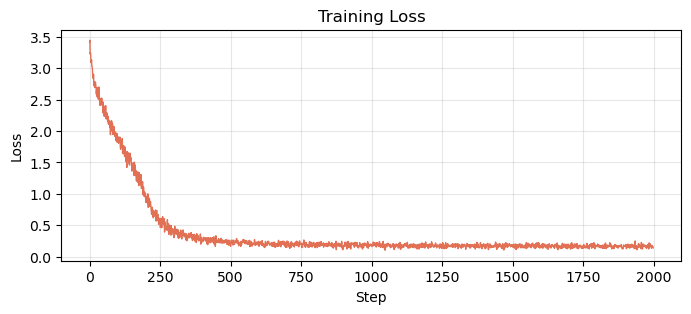


最终 Loss: 0.1413


In [31]:
# ============================================
# 训练 nanoGPT
# ============================================

model = NanoGPT(vocab_size, d_model=128, n_heads=4, d_ff=256, n_layers=3)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

losses = []
for step in range(2000):
    xb, yb = get_batch(train_data)
    opt.zero_grad()
    logits = model(xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (step + 1) % 500 == 0:
        print(f'Step {step+1:>4d}/2000 | Loss = {loss.item():.4f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, lw=1, color='#e17055')
plt.xlabel('Step'); plt.ylabel('Loss')
plt.title('Training Loss'); plt.grid(alpha=0.3)
plt.savefig('day24_nanogpt_loss.png', dpi=100)
plt.show()
print(f'\n最终 Loss: {losses[-1]:.4f}')

In [28]:
# ============================================
# 生成测试: 看看学会了吗
# ============================================

def generate_text(model, prompt, length=60):
    model.eval()
    with torch.no_grad():
        x = torch.LongTensor([[stoi[c] for c in prompt]])
        out = model.generate(x, max_new=length, temperature=0.8)
        return ''.join(itos[int(i)] for i in out[0])

prompts = ['hello', 'machine ', 'gpt ', 'deep ', 'artificial']
for p in prompts:
    result = generate_text(model, p)
    print(f'"{p}" → {result}')

"hello" → hello world
the carhin icee cirn l ig
ncale lrle le ce lsatfoave 
"machine " → machine learning
ining
ineinsfrne ru caleng
inel lruone lntworurml h
"gpt " → gpt is cool
deep rl
d
atwol
dirntrk
dee lstl
dalstrtworl
tl
d
tk
"deep " → deep learning
traratralscontrtrntrsforachon cral lrururnchork
tra
"artificial" → artificial intellintelliceelllllel ll igelelldellentwor cence
telioror


## 5. 跟 GPT-2 对比

| 维度 | nanoGPT (今天) | GPT-2 (昨天) |
|:----|:--------------:|:------------:|
| **参数量** | ~150K | **124M** |
| **磁盘** | 几 KB (就代码) | **526 MB** |
| **训练数据** | 30 行文字 | 40 GB 网页 |
| **训练时间** | 10 秒 | 很多 GPU 天 |
| **效果** | 能学会简单模式 | 能写文章 |
| **理解原理** | ✅ 完全理解 | ❌ 黑盒 |

> nanoGPT 的意义不是"好用", 而是**理解每一步在做什么**
>
> Karpathy 的名言: "I don't understand something until I implement it from scratch."

---

# Day 24 完成!

## 今天实现了什么

```text
CausalSelfAttention → 带因果掩码的多头注意力
TransformerDecoderBlock → Attention + MLP + 残差
NanoGPT → Embedding + N × Decoder + lm_head
generate → 自回归采样生成
```

## nanoGPT 完整架构 (300 行)

```
输入 token IDs
  → Token Embedding + Position Embedding
  → [CausalSelfAttention → Add&Norm → MLP → Add&Norm] × N
  → LayerNorm → Linear → vocab 概率
  → 采样下一个 token → 拼回去 → 继续
```

## 第 4 周剩余内容

| 日期 | 内容 | 说明 |
|:----:|:----|:-----|
| Day 25 | **ViT** | Transformer 做图像分类 |
| Day 26 | **CLIP** | 图文对比学习、多模态 |
| Day 27 | **GAN** | 生成器 vs 判别器 |
| Day 28 | **Stable Diffusion** | 扩散模型、文生图 |

## 作业 (2 题)

### 1. 改模型大小
**位置:** cell-10, `NanoGPT(vocab_size, d_model=64, ...)`

把 `d_model=64` 改成 `32` 或 `128`, 重新训练, 观察:
  - 参数量变化?
  - 生成质量变化?
  - 训练速度变化?

<details>
<summary>📖 答案</summary>
d_model=32: 参数约 40K, 训练更快, 但生成可能更乱
d_model=128: 参数约 500K, 训练稍慢, 但生成更准
太小 → 容量不够学不会; 太大 → 过拟合 (数据只有 30 行)
</details>

### 2. 改 temperature
**位置:** cell-11, `generate_text(model, p, temperature=0.8)`

试试 `temperature=0.1` (保守) 和 `temperature=1.5` (随机), 观察输出差异:

<details>
<summary>📖 答案</summary>
temperature=0.1: 几乎总是选概率最高的词, 输出可能重复循环
temperature=1.5: 随机性大, 可能生成不在训练集中的字符组合
temperature=0.8: 平衡探索和利用, 最常用
</details>